# Qubit Quality Metrics

This tutorial covers benchmarks for measuring fundamental qubit properties.

In [1]:
from qcmet import T1, T2, IdleQubitOscillationFrequency
from qcmet.devices import NoisySimulator
import numpy as np
import matplotlib.pyplot as plt

The qubit quality metrics consist of:

- Qubit relaxation time (T1)

- Qubit dephasing time (T2)

- Idle qubit purity oscillation frequency (IdleQubitOscillationFrequency)


## T1

T1 (relaxation time) measures how long a qubit stays in the excited state before decaying to the ground state.

The T1 benchmark can be executed using idle/identity gates or delay gates. Some QPU hardware will remove identity gates after circuit transpilation, so delay gates can be used instead.

### How T1 Works

1. Prepare qubit in excited state |1⟩ using X gate
2. Wait for various durations (using idle/identity gates or delay gates)
3. Measure the qubit
4. Fit exponential decay: P(1) = A × exp(-t/T1)

The decay rate gives us the T1 time.

### Basic T1 Measurement (Idle Gates)

In [3]:
# Create noisy simulator
device = NoisySimulator()

# Setup T1 benchmark with range of idle gates
num_idle_gates = np.arange(1, 3000, 300)
t1_benchmark = T1(num_idle_gates_per_circ=num_idle_gates)

# Generate circuits
t1_benchmark.generate_circuits()
print(f"Generated {len(t1_benchmark.circuits)} circuits")

Generated 10 circuits


In [23]:
# Look at the first circuit structure
print("First T1 circuit (with 1 idle gate):")
print(t1_benchmark.circuits[0])

First T1 circuit (with 1 idle gate):
        ┌───┐ ░ ┌───┐ ░  ░ ┌─┐
     q: ┤ X ├─░─┤ I ├─░──░─┤M├
        └───┘ ░ └───┘ ░  ░ └╥┘
meas: 1/════════════════════╩═
                            0 


In [4]:
# Run the benchmark
t1_benchmark.run(device, num_shots=2048)

# Analyze results
results = t1_benchmark.analyze()
print("T1 Results:")
for key, value in results.items():
    print(f"  {key}: {value}")

T1 Results:
  success: True
  T1 (t/t_[1q_gate]): 4983.220514654325
  fit: {'popt': array([1.00068918e+00, 4.98322051e+03]), 'pcov': array([[ 4.94906776e-05, -7.17362085e-01],
       [-7.17362085e-01,  1.67935034e+04]])}


### Visualizing T1 Decay

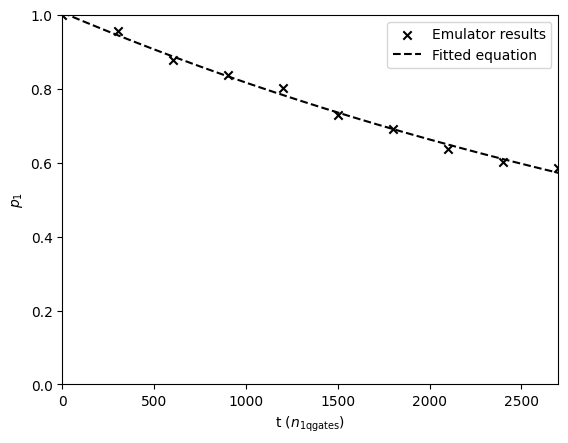

In [ ]:
# Plot the decay
fig, ax = t1_benchmark.plot()
plt.show()

### Basic T1 Measurement (Delay Gates)

This is how the T1 benchmark is initialised with delay gates instead of idle gates. All remaining steps to execute the benchmark are identical to the idle gates approach.

In [7]:
# Setup T1 benchmark with range of delay gates
delay = [1,2,5,10,15,20,25,30,35,45,55,70,100]
t1_benchmark = T1(delay=delay)

## T2

T2 (dephasing time) measures the timescale at which the phase information of a state in superposition is lost.

The T2 benchmark can be executed using idle/identity gates or delay gates. Some QPU hardware will remove identity gates after circuit transpilation, so delay gates can be used instead.

### How T2* (Ramsey) Works

1. Prepare qubit in ground state |0⟩ 
2. Apply Rx($\pi$/2) rotation gate
3. Wait for various durations (using idle/identity gates or delay gates)
4. Measure the qubit
5. Fit exponential decay: P(1)R = A × exp(-t/T2*) cos(2 $\pi$ ft + $\phi$) + b

### How T2 (Hahn) Works

1. Prepare qubit in ground state |0⟩ 
2. Apply Rx($\pi$/2) rotation gate
3. Wait for half of total duration for various durations (using idle/identity gates or delay gates)
4. Apply Rx($\pi$) rotation gate
5. Wait for half of total duration for various durations (using idle/identity gates or delay gates)
6. Measure the qubit
7. Fit exponential decay: P(1)E = A × exp(-t/T2) + B

The decay rate gives us the T2 time.

### Basic T2* (Ramsey) Measurement (Idle Gates)

In [14]:
# Create ideal simulator
device = NoisySimulator()

# Setup T1 benchmark with range of idle gates
num_idle_gates = np.arange(1, 3000, 300)
t2_benchmark = T2(method='ramsey',num_idle_gates_per_circ=num_idle_gates,detuning_phase=np.pi/200)

# Generate circuits
t2_benchmark.generate_circuits()
print(f"Generated {len(t2_benchmark.circuits)} circuits")

Generated 10 circuits


In [15]:
# Run the benchmark
t2_benchmark.run(device, num_shots=2048)

# Analyze results
results = t2_benchmark.analyze()
print("T2 Results:")
for key, value in results.items():
    print(f"  {key}: {value}")

T2 Results:
  success: True
  T2* (t/t_[1q_gate]): 6841.646061120499
  method: ramsey
  fit: {'popt': array([4.98589725e-01, 6.84164606e+03, 2.49837117e-03, 1.75482321e-02,
       5.01227008e-01]), 'pcov': array([[ 7.27604961e-05, -4.00419411e+00, -2.95256724e-10,
         4.82740010e-06, -3.19695397e-06],
       [-4.00419411e+00,  3.77304969e+05,  1.51019183e-05,
        -1.98266560e-01,  4.52455786e-02],
       [-2.95256724e-10,  1.51019183e-05,  4.75659196e-12,
        -3.86961723e-08,  1.01502861e-10],
       [ 4.82740010e-06, -1.98266560e-01, -3.86961723e-08,
         4.47411885e-04, -6.26974238e-06],
       [-3.19695397e-06,  4.52455786e-02,  1.01502861e-10,
        -6.26974238e-06,  1.12026707e-05]])}


### Visualizing T2* Decay

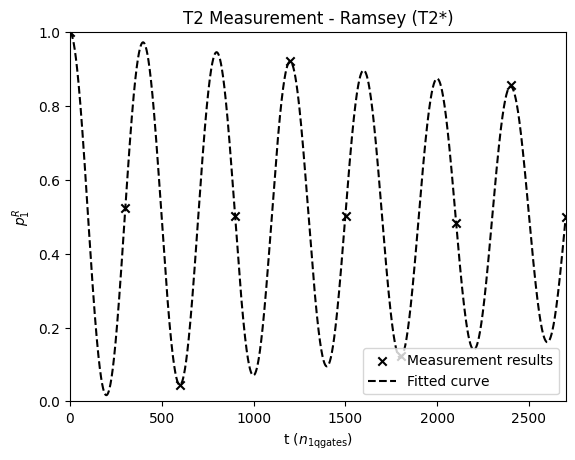

In [16]:
# Plot the decay
fig, ax = t2_benchmark.plot()
plt.show()

## Idle Qubit Oscillation Frequency

An idle qubit periodically losing and regaining coherence can be a signature of non-Markovian noise.

The oscillation frequency of the qubit purity can quantify the effect of non-Markovian noise induced coherence revivals, where a higher frequency indicates larger non-Markovianity of the noise.

### How Idle Qubit Oscillation Frequency Works

1. Select time step (dt) and max time (t_max) to leave qubit idle to get the set of idle times T = {0, dt, 2dt, ..., t_max} for which to run the circuits. 
2. For each initial state |i⟩ ∈ {|0⟩, |+⟩, |R⟩}, perform the following operations:

    a. For each idle time t ∈ T:

    i. For each measurement basis:

     - Prepare qubit in state |i⟩.

     - Leave qubit idle for time t.

     - Measure qubit in basis by applying the corresponding basis change gates and then
    measuring in the computational basis.

    ii. Calculate the purity ζ.

    b. For each initial state |i⟩, fit ζ(t) = a + b * exp(−λt) cos(ωt)  to a decaying oscillation and store the estimated
    oscillation frequency ω_i.

3. The largest oscillation frequency from all three initial states gives the single-qubit non-Markovian noise induced purity oscillation frequency, ω_max.




### Basic Idle Qubit Oscillation Frequency Measurements

In [ ]:
# Create noisy simulator
device = NoisySimulator()

# Setup IdleQubitOscillationFrequency benchmark
idle_qubits_benchmark = IdleQubitOscillationFrequency(0.5, 15, 0.15)

# Generate circuits
idle_qubits_benchmark.generate_circuits()

In [18]:
# Run the benchmark
idle_qubits_benchmark.run(device, num_shots=1000)

# Analyze results
results = idle_qubits_benchmark.analyze()
print("Idle Qubits Oscillation Frequency Results:")
for key, value in results.items():
    print(f"  {key}: {value}")

Idle Qubits Oscillation Frequency Results:
  initial_state_0_purities: [1.002504, 1.00034, 1.00272, 1.0007300000000001, 1.0023440000000001, 1.000002, 1.000016, 1.00353, 1.0011700000000001, 1.000274, 1.0000900000000001, 1.001994, 1.000512, 1.00068, 1.0003279999999999, 1.002768, 1.000202, 1.000712, 1.000848, 1.0005, 1.001282, 1.000178, 1.00005, 1.000178, 1.000072, 1.00004, 1.000288, 1.000032, 1.001556, 1.001682]
  initial_state_0_fit_result: {'popt': array([1.00060176, 0.00128809, 0.12060744, 0.40391297]), 'pcov': array([[ 9.58550260e-08, -1.01789808e-07,  2.62613431e-05,
        -1.02436308e-06],
       [-1.01789808e-07,  5.15525661e-07,  1.90047929e-05,
         6.31675770e-06],
       [ 2.62613431e-05,  1.90047929e-05,  2.19988658e-02,
         1.07937086e-03],
       [-1.02436308e-06,  6.31675770e-06,  1.07937086e-03,
         6.02190877e-03]])}
  initial_state_0_oscillation_frequency: 0.0
  initial_state_+_purities: [1.0001300000000002, 0.9804179999999999, 0.9479259999999999, 0.9122

### Visualizing Oscillation Frequency

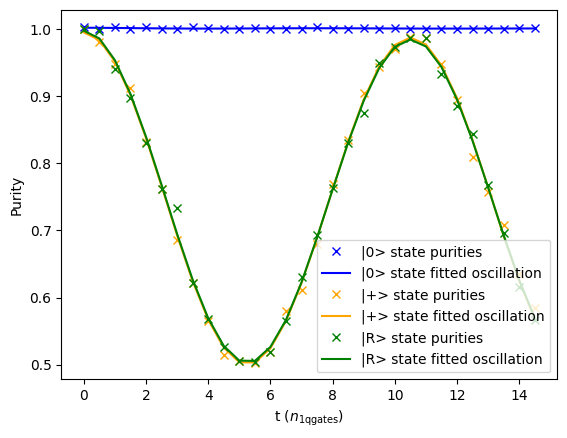

In [19]:
# Plot the oscillation
fig, ax = idle_qubits_benchmark.plot()
plt.show()

## Interpreting Qubit Quality Results

### What the Numbers Mean

**T1 time** (in gate units/microseconds): How many idle gates/time passed before decay
- If using idle gates approach, multiply T1 by gate duration to convert to physical time.
- Longer T1 = better qubit quality

**T2R time** (in gate units/microseconds): How many idle gates/time passed before decay
- If using idle gates approach, multiply T2 by gate duration to convert to physical time.
- Longer T2R = better qubit quality

**T2E time** (in gate units/microseconds): How many idle gates/time passed before decay
- If using idle gates approach, multiply T2 by gate duration to convert to physical time.
- Longer T2E = better qubit quality

**Oscillation frequency** : The largest rate of oscillation in qubit purity amongst the three measurement bases
- Larger oscillation frequency = larger non-Markovianity of the noise.

